In [1]:
# import os
# import shutil
# from sklearn.model_selection import train_test_split
# from tqdm import tqdm

# # Đường dẫn gốc
# root_input = "/kaggle/input/vietnamese-foods/Images"
# combined_dir = "/kaggle/working/combined"
# output_dir = "/kaggle/working/split"  # Chia ra train/val/test ở đây

# # Bước 1: Gộp lại toàn bộ ảnh từ Train/Validate/Test vào combined_dir
# os.makedirs(combined_dir, exist_ok=True)

# for split in ['Train', 'Validate', 'Test']:
#     split_path = os.path.join(root_input, split)
#     for food_class in os.listdir(split_path):
#         class_path = os.path.join(split_path, food_class)
#         if not os.path.isdir(class_path):
#             continue
#         for img_file in os.listdir(class_path):
#             src = os.path.join(class_path, img_file)
#             dst_dir = os.path.join(combined_dir, food_class)
#             os.makedirs(dst_dir, exist_ok=True)
#             dst = os.path.join(dst_dir, f"{split}_{img_file}")
#             shutil.copy(src, dst)

# # Bước 2: Chia theo tỉ lệ 70/15/15
# for food_class in tqdm(os.listdir(combined_dir), desc="Splitting classes"):
#     class_dir = os.path.join(combined_dir, food_class)
#     images = os.listdir(class_dir)
    
#     if len(images) < 10:
#         print(f"❗ Bỏ qua lớp {food_class} vì quá ít ảnh ({len(images)})")
#         continue

#     train_imgs, temp_imgs = train_test_split(images, test_size=0.3, random_state=42)
#     val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.5, random_state=42)

#     for split, img_list in zip(['train', 'val', 'test'], [train_imgs, val_imgs, test_imgs]):
#         split_class_dir = os.path.join(output_dir, split, food_class)
#         os.makedirs(split_class_dir, exist_ok=True)
#         for img in img_list:
#             src = os.path.join(class_dir, img)
#             dst = os.path.join(split_class_dir, img)
#             shutil.copy(src, dst)

# print("✅ Hoàn tất chia lại dữ liệu theo tỉ lệ 70/15/15.")

In [2]:
# import zipfile

# def zip_folder(folder_path, zip_path):
#     with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
#         for root, _, files in os.walk(folder_path):
#             for file in files:
#                 abs_path = os.path.join(root, file)
#                 rel_path = os.path.relpath(abs_path, folder_path)
#                 zf.write(abs_path, rel_path)

# zip_output_path = "/kaggle/working/split_dataset.zip"
# zip_folder(output_dir, zip_output_path)
# print(f"✅ Đã nén dữ liệu chia tỉ lệ vào: {zip_output_path}")

In [3]:
import os
import torch
import torchvision
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torchvision.transforms import ColorJitter, GaussianBlur
import matplotlib.pyplot as plt
from tqdm import tqdm

# ===================== SETUP =====================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_dir = "/kaggle/input/30vnfoods-split"
num_classes = 30
batch_size = 32
epochs = 30

In [4]:
# ===================== TRANSFORMS =====================
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomApply([GaussianBlur(kernel_size=3)], p=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [5]:
# ===================== DATALOADERS =====================
train_set = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=train_transform)
val_set = datasets.ImageFolder(os.path.join(data_dir, 'val'), transform=val_transform)
test_set = datasets.ImageFolder(os.path.join(data_dir, 'test'), transform=val_transform)

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size)
test_loader = DataLoader(test_set, batch_size=batch_size)

In [6]:
# ===================== MODEL =====================
from torchvision import models
import torch.nn as nn

# --- Build model ---
model = models.efficientnet_b0(pretrained=True)

# Cho phép train toàn bộ tham số (full train)
for param in model.parameters():
    param.requires_grad = True

# Thay classifier mới
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(model.classifier[1].in_features, 512),
    nn.ReLU(),
    nn.BatchNorm1d(512),
    nn.Dropout(p=0.3),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.BatchNorm1d(256),
    nn.Dropout(p=0.2),
    nn.Linear(256, num_classes)
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2, verbose=True)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 182MB/s]
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr

Epoch 1/30


✅ Train Loss: 2.4607, Acc: 0.3323 | Val Loss: 1.3198, Acc: 0.6487
🔥 Best model saved with val acc: 0.6487
Epoch 2/30


✅ Train Loss: 1.4156, Acc: 0.6083 | Val Loss: 0.8733, Acc: 0.7464
🔥 Best model saved with val acc: 0.7464
Epoch 3/30


✅ Train Loss: 1.0991, Acc: 0.6884 | Val Loss: 0.7035, Acc: 0.7909
🔥 Best model saved with val acc: 0.7909
Epoch 4/30


✅ Train Loss: 0.9359, Acc: 0.7328 | Val Loss: 0.6233, Acc: 0.8177
🔥 Best model saved with val acc: 0.8177
Epoch 5/30


...

✅ Train Loss: 0.3515, Acc: 0.8977 | Val Loss: 0.4509, Acc: 0.8787
🔥 Best model saved with val acc: 0.8787
Epoch 27/30


✅ Train Loss: 0.3525, Acc: 0.8976 | Val Loss: 0.4610, Acc: 0.8785
⏳ No improvement. EarlyStopping counter: 1/5
Epoch 28/30


✅ Train Loss: 0.3380, Acc: 0.9008 | Val Loss: 0.4533, Acc: 0.8822
🔥 Best model saved with val acc: 0.8822
Epoch 29/30


✅ Train Loss: 0.3411, Acc: 0.8981 | Val Loss: 0.4565, Acc: 0.8777
⏳ No improvement. EarlyStopping counter: 1/5
Epoch 30/30


✅ Train Loss: 0.3400, Acc: 0.9033 | Val Loss: 0.4492, Acc: 0.8769
⏳ No improvement. EarlyStopping counter: 2/5


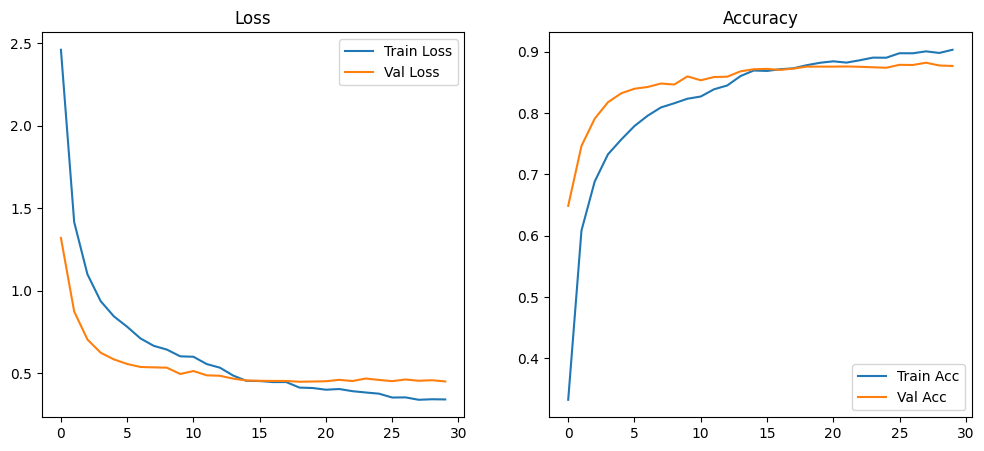

In [7]:
# ===================== TRAIN LOOP =====================
train_loss_list, val_loss_list = [], []
train_acc_list, val_acc_list = [], []

best_acc = 0.0
patience = 5         # số epoch cho phép không cải thiện
counter = 0          # đếm số epoch không cải thiện
os.makedirs("/kaggle/working/checkpoints", exist_ok=True)

for epoch in range(epochs):
    print(f"Epoch {epoch+1}/{epochs}")
    
    model.train()
    running_loss, running_correct = 0.0, 0

    loop = tqdm(train_loader, desc="Training", leave=False)
    for inputs, labels in loop:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_correct += (preds == labels).sum().item()

        loop.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(train_set)
    epoch_acc = running_correct / len(train_set)
    train_loss_list.append(epoch_loss)
    train_acc_list.append(epoch_acc)

    # ==== VALIDATION ====
    model.eval()
    val_loss, val_correct = 0.0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            val_loss += loss.item() * inputs.size(0)
            val_correct += (preds == labels).sum().item()

    val_loss /= len(val_set)
    val_acc = val_correct / len(val_set)
    val_loss_list.append(val_loss)
    val_acc_list.append(val_acc)

    print(f"✅ Train Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f} | Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

    # Cập nhật lr scheduler
    scheduler.step(val_acc)
    
    # ==== Save best ====
    if val_acc > best_acc:
        best_acc = val_acc
        counter = 0
        torch.save(model.state_dict(), "/kaggle/working/checkpoints/best_model.pth")
        print(f"🔥 Best model saved with val acc: {val_acc:.4f}")
    else:
        counter += 1
        print(f"⏳ No improvement. EarlyStopping counter: {counter}/{patience}")
        if counter >= patience:
            print("🛑 Early stopping triggered.")
            break

# ===================== PLOT =====================
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_loss_list, label='Train Loss')
plt.plot(val_loss_list, label='Val Loss')
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_acc_list, label='Train Acc')
plt.plot(val_acc_list, label='Val Acc')
plt.title("Accuracy")
plt.legend()

plt.show()

In [8]:
# Load best model
model.load_state_dict(torch.load("/kaggle/working/checkpoints/best_model.pth"))
model.eval()

test_correct = 0
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Testing"):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        test_correct += (preds == labels).sum().item()

test_acc = test_correct / len(test_set)
print(f"🎯 Final Test Accuracy: {test_acc:.4f}")

Testing: 100%|██████████| 119/119 [01:28<00:00,  1.35it/s]

🎯 Final Test Accuracy: 0.8879
